# Tugas Data Science (IF404) - Project-Based Learning
## Analisis Buku Impor pada E-Commerce Periplus.com

**Dosen Pengampu:** Ir. Ahmad Chusyairi, M.Com., CDS., IPM., ASEAN Eng  
**Anggota Kelompok:**
1. Sutan Gading Fadhillah Nasution (250401020159)
2. Rina Mardiana (250401020151)

**Program Studi:** PJJ Informatika S1

---

## 1. Manajemen Data

Manajemen data mencakup proses pengumpulan, pemeriksaan kualitas, pembersihan, transformasi, dan persiapan dataset sebelum digunakan untuk analisis lebih lanjut.
Dataset dikumpulkan melalui web scraping dari situs Periplus.com.

### 1.1 Import Library & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
PLOTS_DIR = '../plots/'
os.makedirs(PLOTS_DIR, exist_ok=True)

df = pd.read_csv('../data/periplus_books_clean.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(5)

Dataset loaded: 1,322 rows x 23 columns


,title,author,binding,in_stock,category,product_url,price_idr,original_price_idr,discount_percent,isbn,...,language,weight,review_count,publication_year,book_age,price_per_page,popularity_score,is_new_release,price_category,has_discount
0,Days at the Morisaki Bookshop,"Yagisawa, Satoshi",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9781786583239/days-a...,258000.0,258000.0,0.0,9.781787e+12,...,English UK / Other,0.17,4,2023.0,3.0,1612.500000,4.00,0,Premium,0
1,The Housemaid,"McFadden, Freida",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9781538742570/the-ho...,258000.0,258000.0,0.0,9.781539e+12,...,English,0.27,4,NaN,-1.0,767.857143,4.00,0,Premium,0
2,Project Hail Mary,"Weir, Andy",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9780593135228/projec...,248000.0,358000.0,31.0,9.780593e+12,...,English,0.34,1,NaN,-1.0,500.000000,1.31,0,Mid-range,1
3,Batman: Hush: DC Compact Comics Edition,"Loeb, Jeph",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9781779527264/batman...,198000.0,198000.0,0.0,9.781780e+12,...,English,0.36,1,NaN,-1.0,634.615385,1.00,0,Mid-range,0
4,Strange Pictures,Uketsu,Paperback,1,Fiction & Literature,http://www.periplus.com/p/9780063433083/strang...,360000.0,360000.0,0.0,9.780063e+12,...,English,0.23,5,NaN,-1.0,1500.000000,5.00,0,Premium,0


### 1.2 Struktur & Info Dataset

In [2]:
df.info()
print(f'\nDuplikat: {df.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1322 non-null   str    
 1   author              1322 non-null   str    
 2   binding             1322 non-null   str    
 3   in_stock            1322 non-null   int64  
 4   category            1322 non-null   str    
 5   product_url         1322 non-null   str    
 6   price_idr           1322 non-null   float64
 7   original_price_idr  1322 non-null   float64
 8   discount_percent    1322 non-null   float64
 9   isbn                1321 non-null   float64
 10  publisher           1322 non-null   str    
 11  publication_date    1321 non-null   str    
 12  pages               1321 non-null   float64
 13  language            1322 non-null   str    
 14  weight              1321 non-null   float64
 15  review_count        1322 non-null   int64  
 16  publication_year 

### 1.3 Missing Values

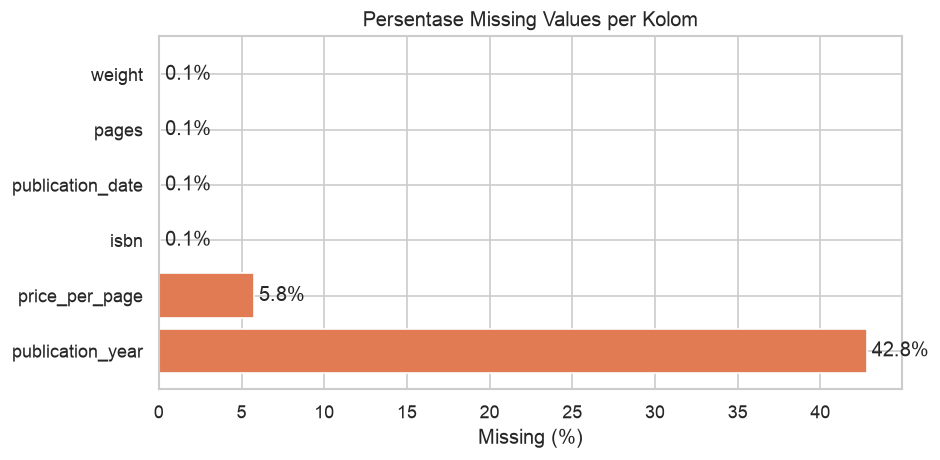

,Count,%
publication_year,566,42.81
price_per_page,76,5.75
isbn,1,0.08
publication_date,1,0.08
pages,1,0.08
weight,1,0.08


In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('%', ascending=False)

if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(missing_df.index, missing_df['%'], color='#e07b54')
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set_xlabel('Missing (%)')
    ax.set_title('Persentase Missing Values per Kolom')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR + '1_missing_values.png', bbox_inches='tight')
    plt.show()

missing_df

### 1.4 Statistik Deskriptif

In [4]:
num_cols = ['price_idr', 'original_price_idr', 'discount_percent', 'pages', 'weight', 'review_count']
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price_idr,1322.0,376616.11,263249.31,29400.0,225000.00,299000.00,446000.00,1975000.00
original_price_idr,1322.0,405618.76,259037.96,78000.0,250000.00,341000.00,455000.00,2380000.00
discount_percent,1322.0,7.78,17.61,0.0,0.00,0.00,0.00,92.00
pages,1321.0,258.30,169.22,0.0,144.00,240.00,352.00,1472.00
weight,1321.0,0.47,0.39,0.0,0.25,0.36,0.57,3.95
review_count,1322.0,0.31,1.01,0.0,0.00,0.00,0.00,20.00


### 1.5 Distribusi Kategori Buku

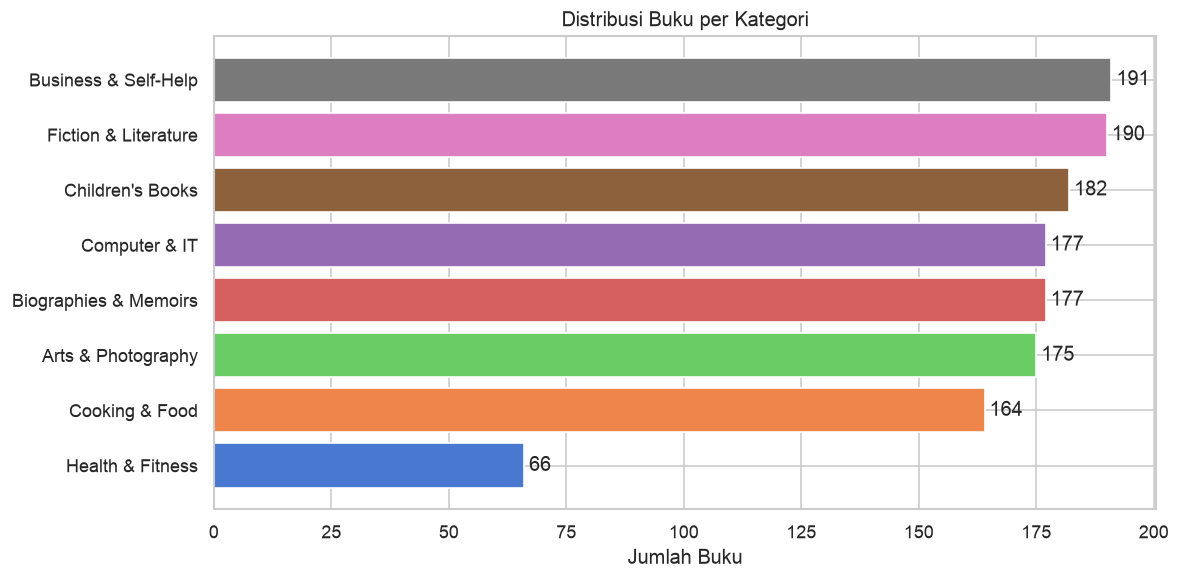

In [5]:
cat_counts = df['category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1],
               color=sns.color_palette('muted', len(cat_counts)))
ax.bar_label(bars, padding=3)
ax.set_xlabel('Jumlah Buku')
ax.set_title('Distribusi Buku per Kategori')
plt.tight_layout()
plt.savefig(PLOTS_DIR + '1_distribusi_kategori.png', bbox_inches='tight')
plt.show()

### 1.6 Distribusi Harga

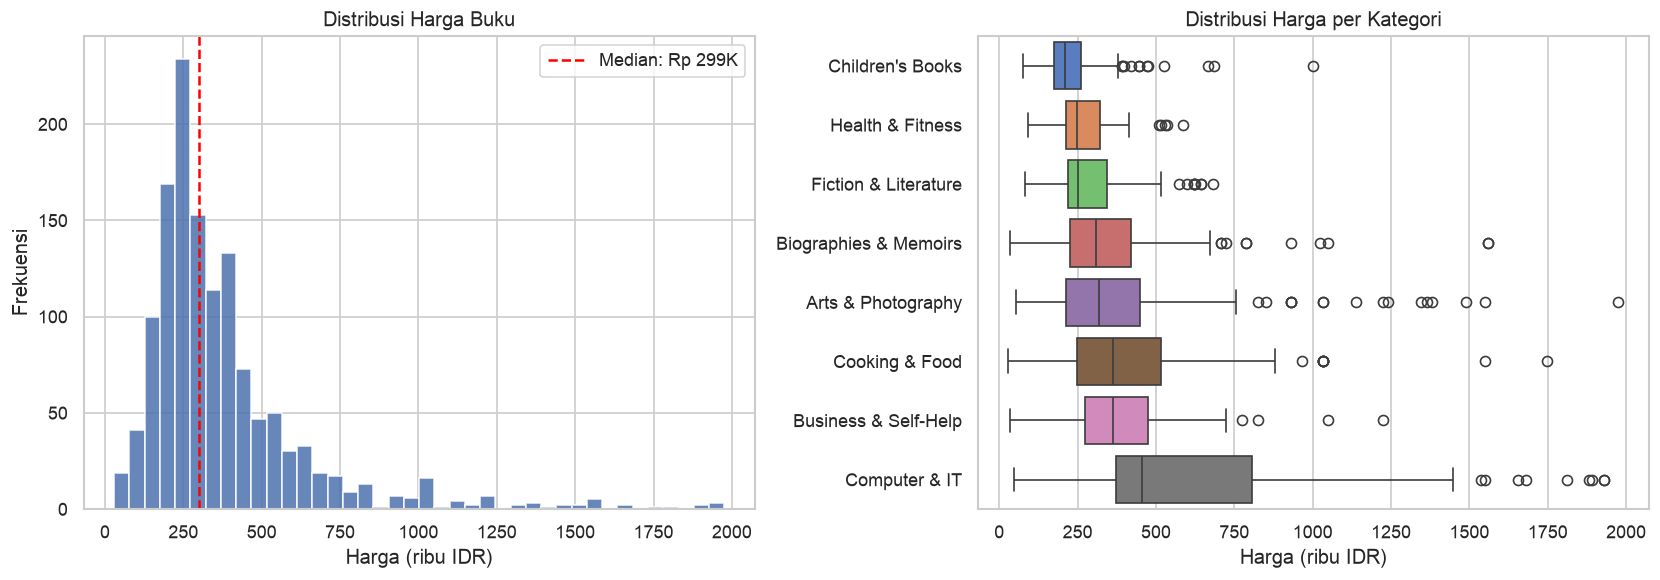

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price_idr'] / 1000, bins=40, color='#4c72b0', edgecolor='white', alpha=0.85)
axes[0].axvline(df['price_idr'].median() / 1000, color='red', linestyle='--',
                label=f"Median: Rp {df['price_idr'].median()/1000:.0f}K")
axes[0].set_xlabel('Harga (ribu IDR)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Harga Buku')
axes[0].legend()

cat_order = df.groupby('category')['price_idr'].median().sort_values().index
df_plot = df.copy()
df_plot['price_k'] = df_plot['price_idr'] / 1000
sns.boxplot(data=df_plot, y='category', x='price_k', order=cat_order, ax=axes[1], palette='muted')
axes[1].set_xlabel('Harga (ribu IDR)')
axes[1].set_ylabel('')
axes[1].set_title('Distribusi Harga per Kategori')

plt.tight_layout()
plt.savefig(PLOTS_DIR + '1_distribusi_harga.png', bbox_inches='tight')
plt.show()

### 1.7 Status Stok & Diskon

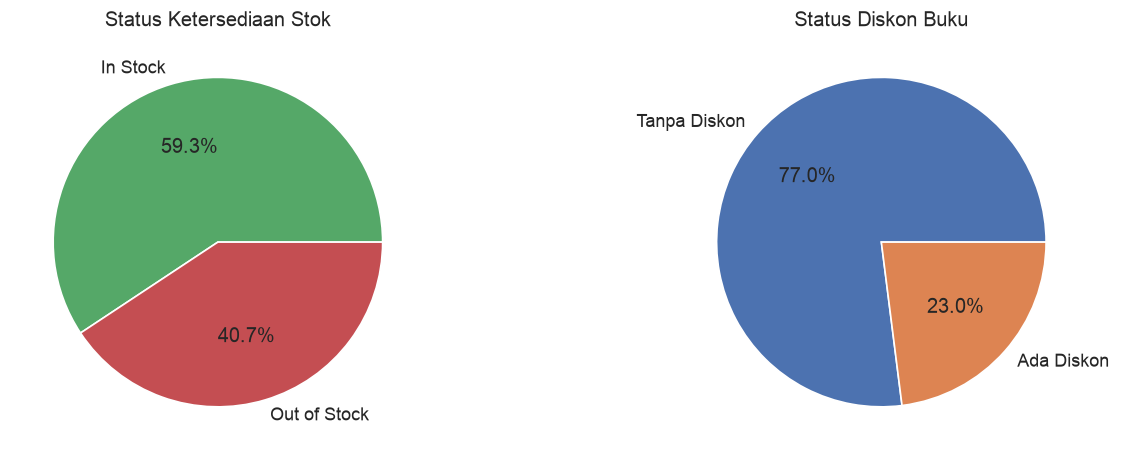

In Stock   : 784 (59.3%)
Ada Diskon : 304 (23.0%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stock_counts = df['in_stock'].value_counts().rename({1: 'In Stock', 0: 'Out of Stock'})
axes[0].pie(stock_counts.values, labels=stock_counts.index, autopct='%1.1f%%', colors=['#55a868', '#c44e52'])
axes[0].set_title('Status Ketersediaan Stok')

disc_counts = df['has_discount'].value_counts().rename({1: 'Ada Diskon', 0: 'Tanpa Diskon'})
axes[1].pie(disc_counts.values, labels=disc_counts.index, autopct='%1.1f%%', colors=['#4c72b0', '#dd8452'])
axes[1].set_title('Status Diskon Buku')

plt.tight_layout()
plt.savefig(PLOTS_DIR + '1_stok_diskon.png', bbox_inches='tight')
plt.show()

print(f"In Stock   : {df['in_stock'].sum():,} ({df['in_stock'].mean()*100:.1f}%)")
print(f"Ada Diskon : {df['has_discount'].sum():,} ({df['has_discount'].mean()*100:.1f}%)")

---
## 2. Korelasi Data

Analisis korelasi mengukur kekuatan dan arah hubungan antara dua variabel numerik. Nilai korelasi Pearson (r) berkisar dari **-1** hingga **+1**.

### 2.1 Correlation Matrix

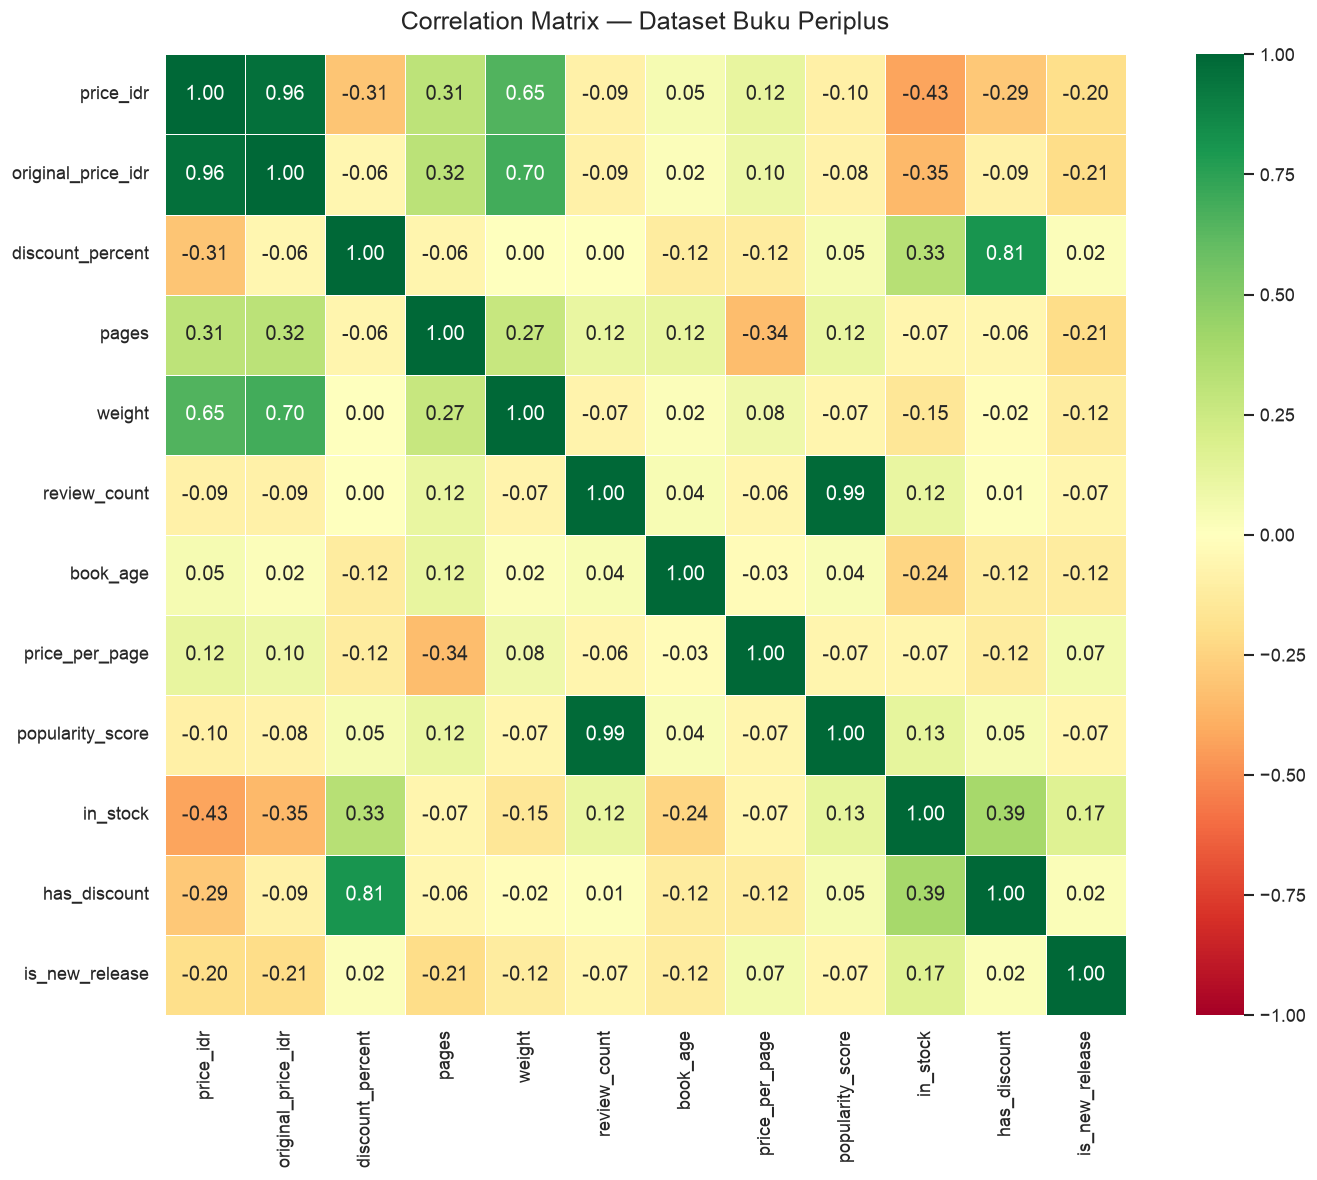

In [8]:
corr_cols = ['price_idr', 'original_price_idr', 'discount_percent',
             'pages', 'weight', 'review_count', 'book_age',
             'price_per_page', 'popularity_score', 'in_stock', 'has_discount', 'is_new_release']

corr_matrix = df[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Matrix — Dataset Buku Periplus', fontsize=15, pad=15)
plt.tight_layout()
plt.savefig(PLOTS_DIR + '2_correlation_matrix.png', bbox_inches='tight')
plt.show()

### 2.2 Korelasi: Harga vs Jumlah Halaman

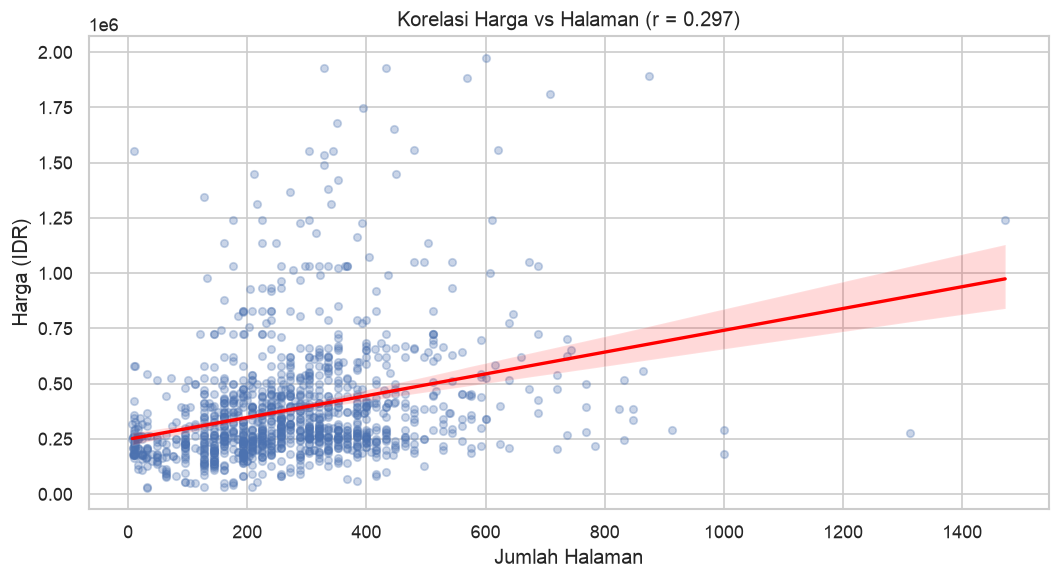

Pearson r = 0.2972


In [9]:
df_s = df[(df['pages'] > 0) & (df['price_idr'] > 0)].copy()
r = df_s[['price_idr', 'pages']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(data=df_s, x='pages', y='price_idr',
            scatter_kws={'alpha': 0.3, 's': 20, 'color': '#4c72b0'},
            line_kws={'color': 'red', 'linewidth': 2}, ax=ax)
ax.set_xlabel('Jumlah Halaman')
ax.set_ylabel('Harga (IDR)')
ax.set_title(f'Korelasi Harga vs Halaman (r = {r:.3f})')
plt.tight_layout()
plt.savefig(PLOTS_DIR + '2_korelasi_harga_halaman.png', bbox_inches='tight')
plt.show()
print(f'Pearson r = {r:.4f}')

### 2.3 Korelasi: Harga vs Berat Buku

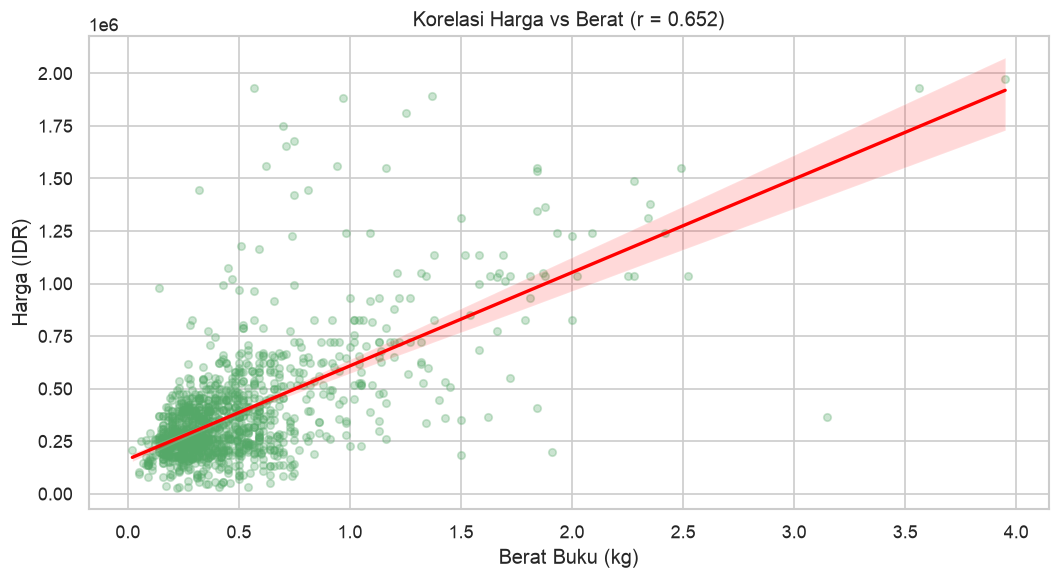

Pearson r = 0.6518


In [10]:
df_w = df[(df['weight'] > 0) & (df['price_idr'] > 0)].copy()
r_w = df_w[['price_idr', 'weight']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(data=df_w, x='weight', y='price_idr',
            scatter_kws={'alpha': 0.3, 's': 20, 'color': '#55a868'},
            line_kws={'color': 'red', 'linewidth': 2}, ax=ax)
ax.set_xlabel('Berat Buku (kg)')
ax.set_ylabel('Harga (IDR)')
ax.set_title(f'Korelasi Harga vs Berat (r = {r_w:.3f})')
plt.tight_layout()
plt.savefig(PLOTS_DIR + '2_korelasi_harga_berat.png', bbox_inches='tight')
plt.show()
print(f'Pearson r = {r_w:.4f}')

### 2.4 Korelasi: Halaman vs Berat

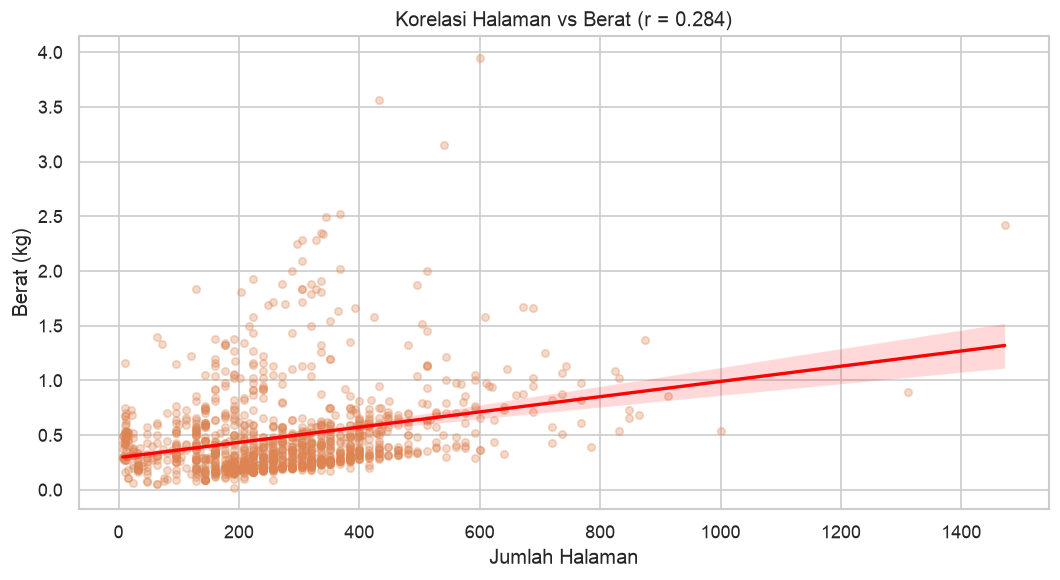

Pearson r = 0.2835


In [11]:
df_pw = df[(df['weight'] > 0) & (df['pages'] > 0)].copy()
r_pw = df_pw[['pages', 'weight']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(data=df_pw, x='pages', y='weight',
            scatter_kws={'alpha': 0.3, 's': 20, 'color': '#dd8452'},
            line_kws={'color': 'red', 'linewidth': 2}, ax=ax)
ax.set_xlabel('Jumlah Halaman')
ax.set_ylabel('Berat (kg)')
ax.set_title(f'Korelasi Halaman vs Berat (r = {r_pw:.3f})')
plt.tight_layout()
plt.savefig(PLOTS_DIR + '2_korelasi_halaman_berat.png', bbox_inches='tight')
plt.show()
print(f'Pearson r = {r_pw:.4f}')

---
## 3. Asosiasi Data

Analisis asosiasi digunakan untuk menemukan pola hubungan antar item. Kita mencari pola asosiasi antara kategori, publisher, binding, dan fitur harga.

### 3.1 Co-occurrence: Category x Publisher

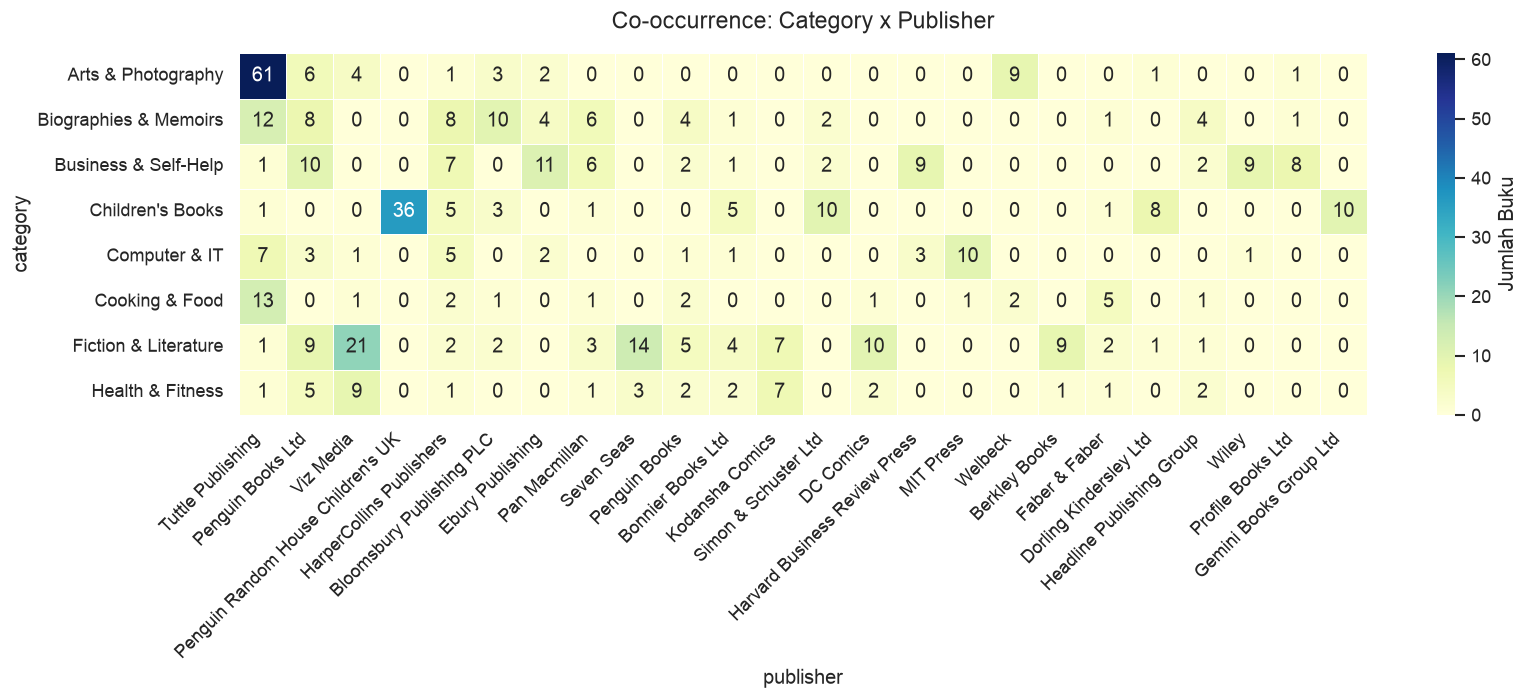

In [12]:
crosstab = pd.crosstab(df['category'], df['publisher'])
top_pubs = df['publisher'].value_counts()[lambda x: x >= 10].index.tolist()
crosstab_filtered = crosstab[top_pubs]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(crosstab_filtered, annot=True, fmt='d', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Jumlah Buku'}, ax=ax)
ax.set_title('Co-occurrence: Category x Publisher', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(PLOTS_DIR + '3_cooccurrence_category_publisher.png', bbox_inches='tight')
plt.show()

### 3.2 Asosiasi: Category x Binding

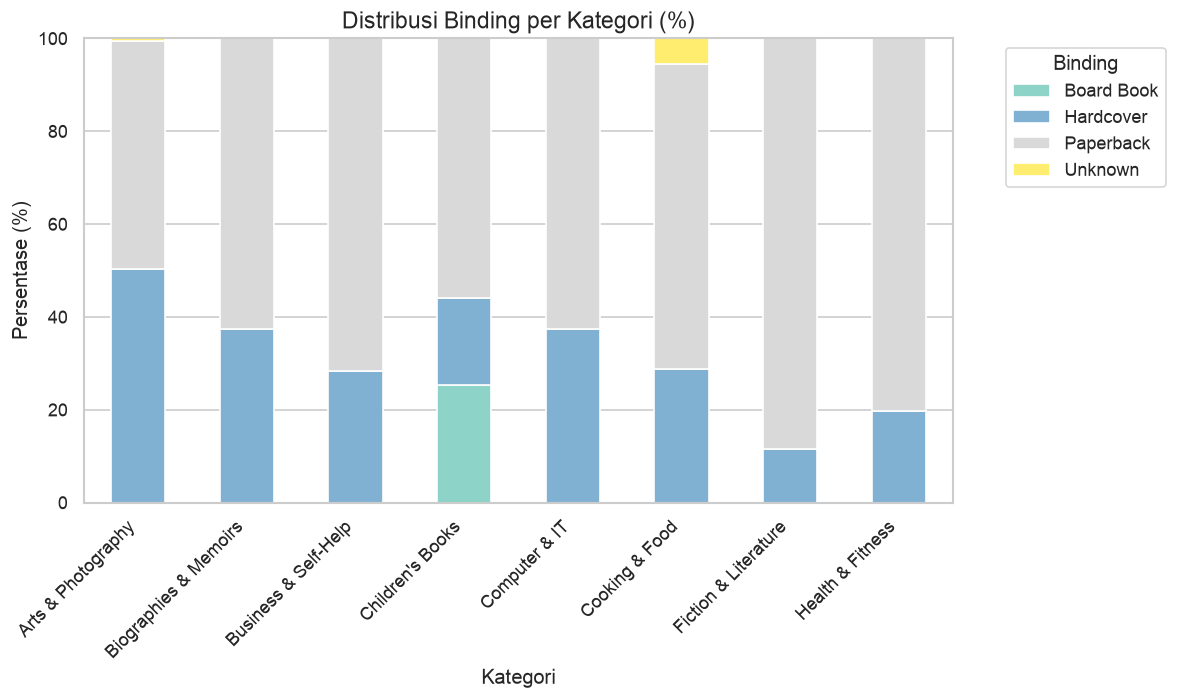

binding,Board Book,Hardcover,Paperback,Unknown
category,,,,
Arts & Photography,0.0,50.3,49.1,0.6
Biographies & Memoirs,0.0,37.3,62.7,0.0
Business & Self-Help,0.0,28.3,71.7,0.0
Children's Books,25.3,18.7,56.0,0.0
Computer & IT,0.0,37.3,62.7,0.0
Cooking & Food,0.0,28.7,65.9,5.5
Fiction & Literature,0.0,11.6,88.4,0.0
Health & Fitness,0.0,19.7,80.3,0.0


In [13]:
ct_binding = pd.crosstab(df['category'], df['binding'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
ct_binding.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', edgecolor='white')
ax.set_title('Distribusi Binding per Kategori (%)', fontsize=14)
ax.set_xlabel('Kategori')
ax.set_ylabel('Persentase (%)')
ax.legend(title='Binding', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(PLOTS_DIR + '3_asosiasi_category_binding.png', bbox_inches='tight')
plt.show()

ct_binding.round(1)

### 3.3 Asosiasi: Price Category x Discount

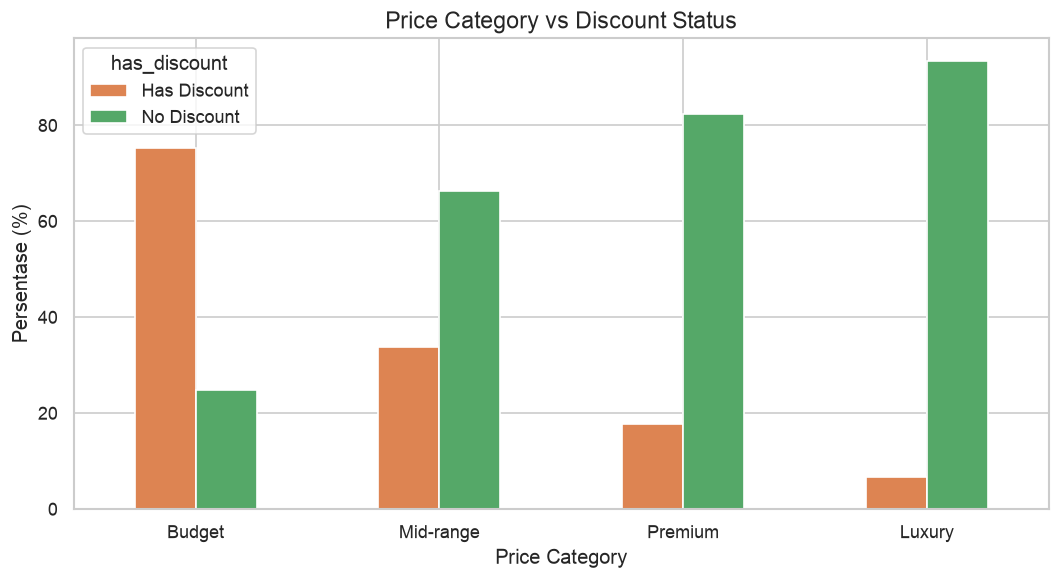

has_discount,Has Discount,No Discount
price_category,,
Budget,75.3,24.7
Mid-range,33.8,66.2
Premium,17.7,82.3
Luxury,6.6,93.4


In [14]:
ct_pd = pd.crosstab(
    df['price_category'],
    df['has_discount'].map({0: 'No Discount', 1: 'Has Discount'}),
    normalize='index') * 100

order = ['Budget', 'Mid-range', 'Premium', 'Luxury']
ct_pd = ct_pd.reindex([x for x in order if x in ct_pd.index])

fig, ax = plt.subplots(figsize=(9, 5))
ct_pd.plot(kind='bar', ax=ax, color=['#dd8452', '#55a868'], edgecolor='white')
ax.set_title('Price Category vs Discount Status', fontsize=14)
ax.set_xlabel('Price Category')
ax.set_ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR + '3_asosiasi_price_discount.png', bbox_inches='tight')
plt.show()

ct_pd.round(1)

### 3.4 Top Publisher x Category Associations

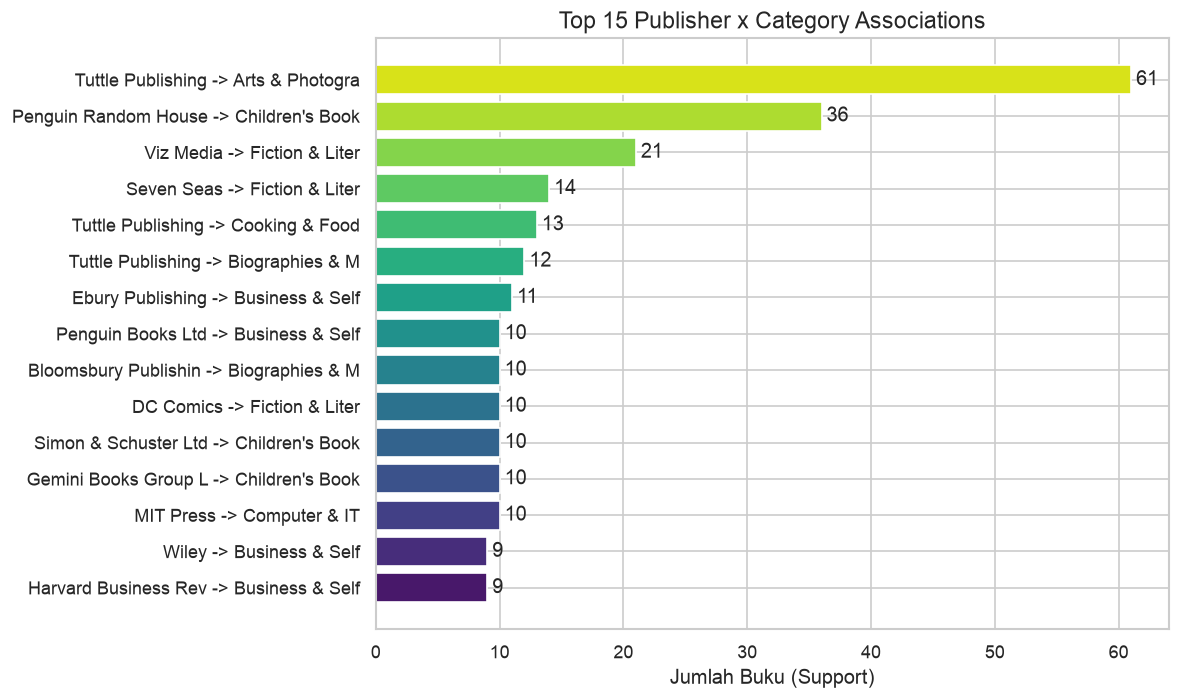

In [15]:
assoc = df.groupby(['publisher', 'category']).size().reset_index(name='count')
assoc = assoc[assoc['count'] >= 5].sort_values('count', ascending=False)
top15 = assoc.head(15).copy()
top15['label'] = top15['publisher'].str[:20] + ' -> ' + top15['category'].str[:15]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15['label'][::-1], top15['count'][::-1],
               color=sns.color_palette('viridis', 15))
ax.bar_label(bars, padding=3)
ax.set_xlabel('Jumlah Buku (Support)')
ax.set_title('Top 15 Publisher x Category Associations', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR + '3_top_associations.png', bbox_inches='tight')
plt.show()

---
## 4. Analisis Regresi

Regresi digunakan untuk memprediksi nilai kontinu. Kita akan memprediksi **harga buku** (`price_idr`) berdasarkan fitur-fitur seperti jumlah halaman, berat, kategori, dan lainnya.

### 4.1 Persiapan Data untuk Regresi

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

df_reg = df[(df['pages'].notna()) & (df['weight'].notna()) &
            (df['price_idr'] > 0) & (df['book_age'] >= 0)].copy()

le_cat = LabelEncoder()
le_pub = LabelEncoder()
le_bind = LabelEncoder()
df_reg['category_enc'] = le_cat.fit_transform(df_reg['category'])
df_reg['publisher_enc'] = le_pub.fit_transform(df_reg['publisher'])
df_reg['binding_enc'] = le_bind.fit_transform(df_reg['binding'])

features = ['pages', 'weight', 'book_age', 'review_count',
            'discount_percent', 'category_enc', 'publisher_enc', 'binding_enc']
X = df_reg[features]
y = df_reg['price_idr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Data: {len(df_reg):,} | Train: {len(X_train):,} | Test: {len(X_test):,}')

Data: 756 | Train: 604 | Test: 152


### 4.2 Linear Regression

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f'R2   : {r2_lr:.4f}')
print(f'RMSE : Rp {rmse_lr:,.0f}')
print(f'MAE  : Rp {mae_lr:,.0f}')

R2   : 0.6270
RMSE : Rp 148,121
MAE  : Rp 99,181


### 4.3 Random Forest Regressor

In [18]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f'R2   : {r2_rf:.4f}')
print(f'RMSE : Rp {rmse_rf:,.0f}')
print(f'MAE  : Rp {mae_rf:,.0f}')

R2   : 0.5714
RMSE : Rp 158,769
MAE  : Rp 83,122


### 4.4 Feature Importance & Actual vs Predicted

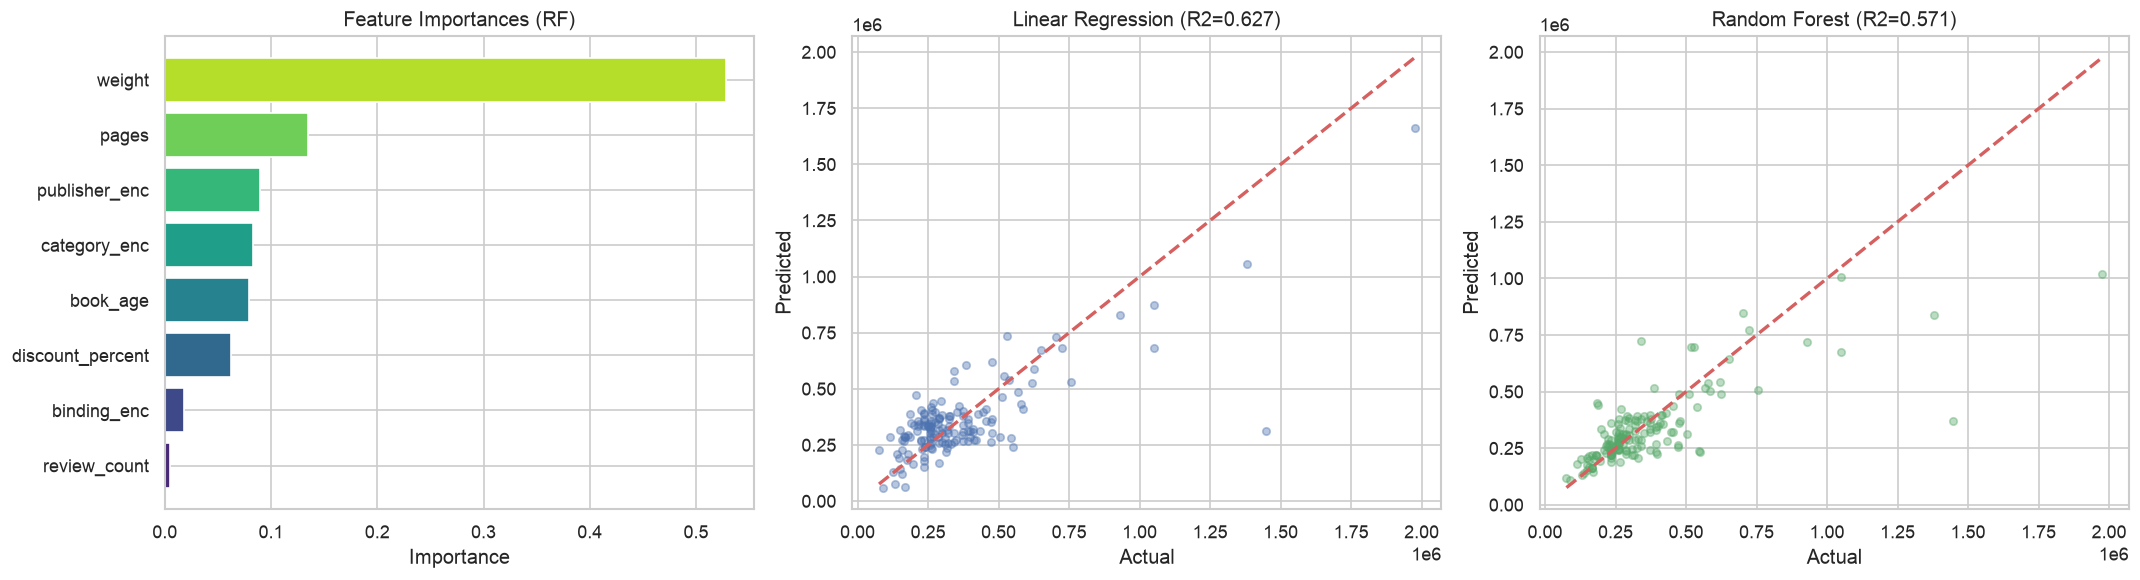

In [19]:
feat_imp = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
feat_imp = feat_imp.sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1],
             color=sns.color_palette('viridis', len(feat_imp)))
axes[0].set_xlabel('Importance')
axes[0].set_title('Feature Importances (RF)')

axes[1].scatter(y_test, y_pred_lr, alpha=0.4, s=20, color='#4c72b0')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Linear Regression (R2={r2_lr:.3f})')

axes[2].scatter(y_test, y_pred_rf, alpha=0.4, s=20, color='#55a868')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Random Forest (R2={r2_rf:.3f})')

plt.tight_layout()
plt.savefig(PLOTS_DIR + '4_regresi_results.png', bbox_inches='tight')
plt.show()

---
## 5. Klasifikasi Data

Klasifikasi adalah teknik supervised learning untuk memprediksi kategori/kelas dari data. Kita membangun 3 model klasifikasi.

### 5.1 Klasifikasi Popularitas Buku (Popular vs Unpopular)

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

df_cls = df[(df['pages'].notna()) & (df['weight'].notna())].copy()
df_cls['is_popular'] = (df_cls['review_count'] > 0).astype(int)
df_cls['category_enc'] = LabelEncoder().fit_transform(df_cls['category'])
df_cls['publisher_enc'] = LabelEncoder().fit_transform(df_cls['publisher'])
df_cls['binding_enc'] = LabelEncoder().fit_transform(df_cls['binding'])

feat_cls = ['price_idr', 'pages', 'weight', 'discount_percent',
            'book_age', 'category_enc', 'publisher_enc', 'binding_enc']

X1 = df_cls[feat_cls]
y1 = df_cls['is_popular']
X1_tr, X1_te, y1_tr, y1_te = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)

rf1 = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf1.fit(X1_tr, y1_tr)
y1_pred = rf1.predict(X1_te)

print(f'Accuracy: {accuracy_score(y1_te, y1_pred):.4f}')
print(f'F1-Score: {f1_score(y1_te, y1_pred):.4f}')
print()
print(classification_report(y1_te, y1_pred, target_names=['Unpopular', 'Popular']))

Accuracy: 0.8226
F1-Score: 0.1754

              precision    recall  f1-score   support

   Unpopular       0.86      0.95      0.90       224
     Popular       0.31      0.12      0.18        41

    accuracy                           0.82       265
   macro avg       0.58      0.54      0.54       265
weighted avg       0.77      0.82      0.79       265



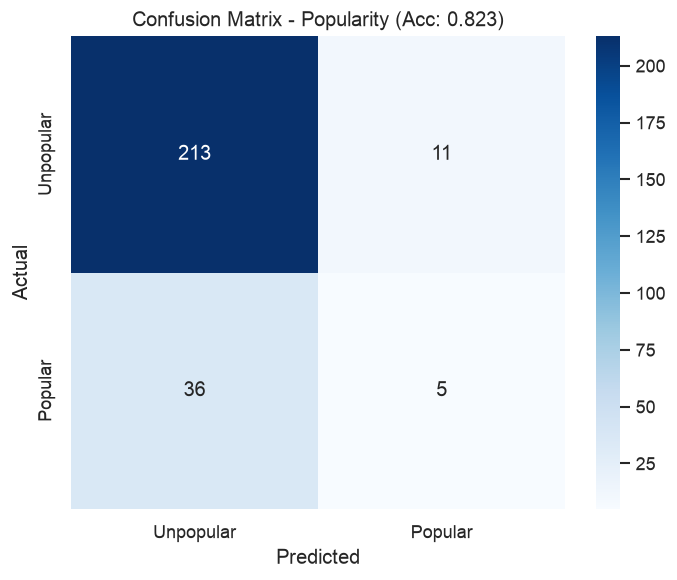

In [21]:
cm1 = confusion_matrix(y1_te, y1_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unpopular', 'Popular'],
            yticklabels=['Unpopular', 'Popular'], ax=ax)
ax.set_title(f'Confusion Matrix - Popularity (Acc: {accuracy_score(y1_te, y1_pred):.3f})')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(PLOTS_DIR + '5_cm_popularity.png', bbox_inches='tight')
plt.show()

### 5.2 Klasifikasi Price Category

In [22]:
le_pc = LabelEncoder()
df_cls['price_cat_enc'] = le_pc.fit_transform(df_cls['price_category'])

feat_cls2 = ['pages', 'weight', 'discount_percent', 'book_age',
             'review_count', 'category_enc', 'publisher_enc', 'binding_enc']

X2 = df_cls[feat_cls2]
y2 = df_cls['price_cat_enc']
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

rf2 = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf2.fit(X2_tr, y2_tr)
y2_pred = rf2.predict(X2_te)

print(f'Accuracy: {accuracy_score(y2_te, y2_pred):.4f}')
print()
print(classification_report(y2_te, y2_pred, target_names=le_pc.classes_))

Accuracy: 0.6868

              precision    recall  f1-score   support

      Budget       1.00      0.55      0.71        20
      Luxury       0.79      0.72      0.75        79
   Mid-range       0.65      0.71      0.68        72
     Premium       0.61      0.67      0.64        94

    accuracy                           0.69       265
   macro avg       0.76      0.66      0.70       265
weighted avg       0.70      0.69      0.69       265



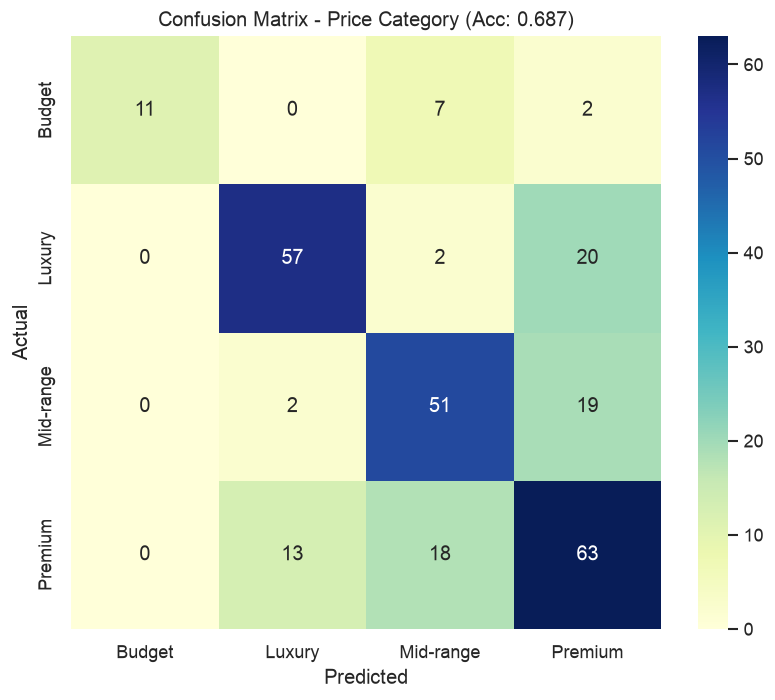

In [23]:
cm2 = confusion_matrix(y2_te, y2_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le_pc.classes_, yticklabels=le_pc.classes_, ax=ax)
ax.set_title(f'Confusion Matrix - Price Category (Acc: {accuracy_score(y2_te, y2_pred):.3f})')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(PLOTS_DIR + '5_cm_price_category.png', bbox_inches='tight')
plt.show()

### 5.3 Klasifikasi Has Discount

In [24]:
feat_cls3 = ['original_price_idr', 'pages', 'weight', 'book_age',
             'review_count', 'category_enc', 'publisher_enc', 'binding_enc']

X3 = df_cls[feat_cls3]
y3 = df_cls['has_discount']
X3_tr, X3_te, y3_tr, y3_te = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

rf3 = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf3.fit(X3_tr, y3_tr)
y3_pred = rf3.predict(X3_te)

print(f'Accuracy: {accuracy_score(y3_te, y3_pred):.4f}')
print(f'F1-Score: {f1_score(y3_te, y3_pred):.4f}')
print()
print(classification_report(y3_te, y3_pred, target_names=['No Discount', 'Has Discount']))

Accuracy: 0.7925
F1-Score: 0.3956

              precision    recall  f1-score   support

 No Discount       0.82      0.94      0.87       204
Has Discount       0.60      0.30      0.40        61

    accuracy                           0.79       265
   macro avg       0.71      0.62      0.64       265
weighted avg       0.77      0.79      0.76       265



---
## 6. Clustering Data

Clustering adalah teknik unsupervised learning untuk mengelompokkan data berdasarkan kesamaan fitur. Kita menggunakan **K-Means Clustering**.

### 6.1 Persiapan Data & Elbow Method

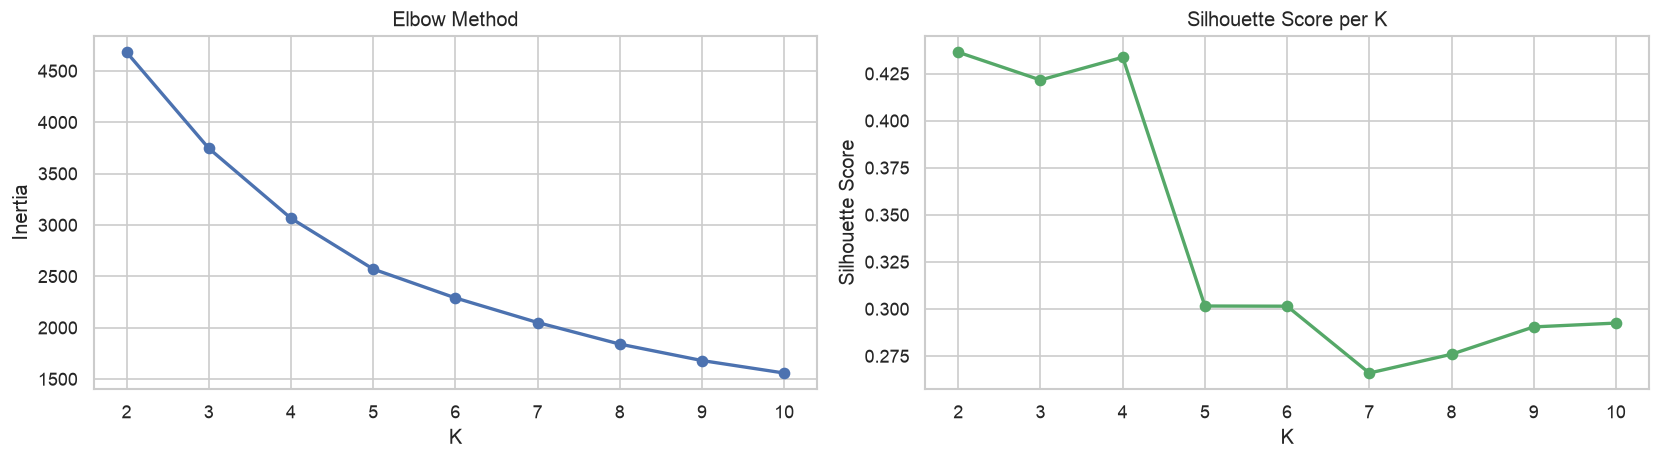

Data: 1,230 rows | Features: ['price_idr', 'pages', 'weight', 'review_count', 'discount_percent']


In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

df_clust = df[(df['pages'] > 0) & (df['weight'] > 0) & (df['price_idr'] > 0)].copy()
cluster_features = ['price_idr', 'pages', 'weight', 'review_count', 'discount_percent']
X_clust = df_clust[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

inertias, sils = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_range, inertias, marker='o', lw=2, color='#4c72b0')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[1].plot(K_range, sils, marker='o', lw=2, color='#55a868')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K')
plt.tight_layout()
plt.savefig(PLOTS_DIR + '6_elbow_method.png', bbox_inches='tight')
plt.show()

print(f'Data: {len(df_clust):,} rows | Features: {cluster_features}')

### 6.2 K-Means Clustering (K=4)

In [26]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clust['cluster'] = kmeans.fit_predict(X_scaled)

print(f'Silhouette Score: {silhouette_score(X_scaled, df_clust["cluster"]):.4f}')
print()

profile = df_clust.groupby('cluster')[cluster_features].mean().round(1)
profile['count'] = df_clust.groupby('cluster').size()
print('Cluster Profile (Mean):')
profile

Silhouette Score: 0.4337

Cluster Profile (Mean):


,price_idr,pages,weight,review_count,discount_percent,count
cluster,,,,,,
0,328957.4,241.2,0.4,0.1,2.4,864
1,879316.6,430.4,1.2,0.1,2.2,163
2,299791.5,343.2,0.3,3.1,6.0,82
3,171521.9,242.8,0.5,0.2,51.7,121


### 6.3 Visualisasi Cluster (PCA 2D)

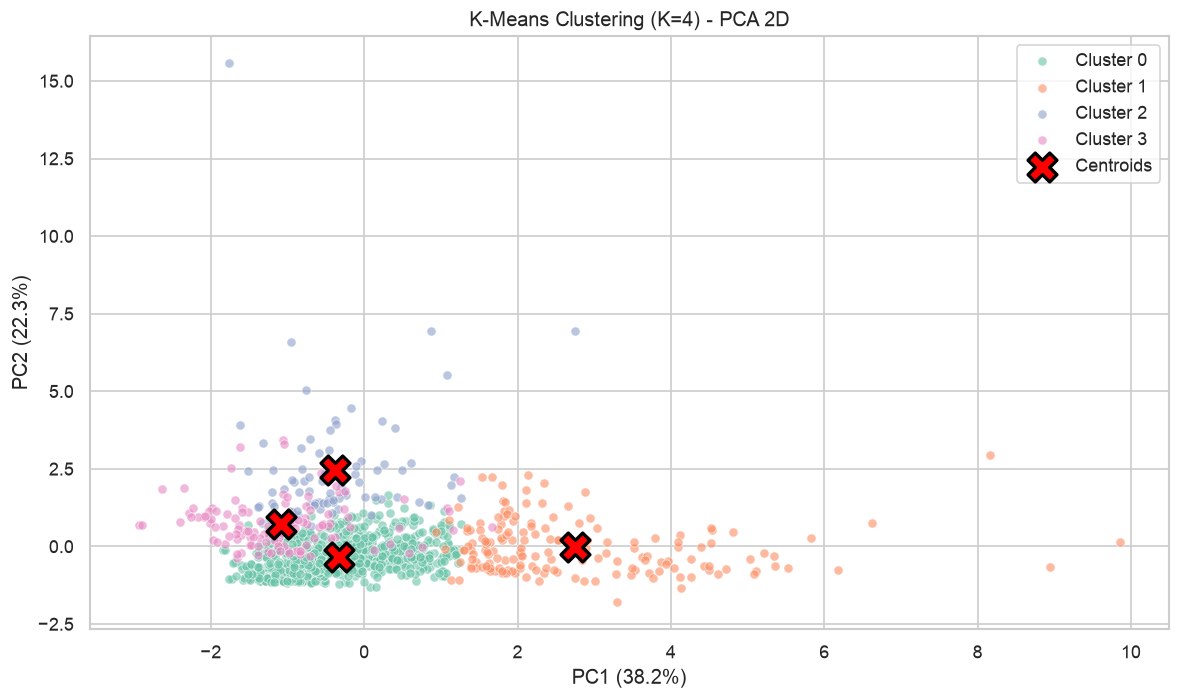

In [27]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_clust['pca1'] = X_pca[:, 0]
df_clust['pca2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Set2', optimal_k)
for i in range(optimal_k):
    d = df_clust[df_clust['cluster'] == i]
    ax.scatter(d['pca1'], d['pca2'], c=[colors[i]], label=f'Cluster {i}',
               alpha=0.6, s=30, edgecolors='white', linewidth=0.5)

centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X',
           s=300, edgecolors='black', linewidth=2, label='Centroids', zorder=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'K-Means Clustering (K={optimal_k}) - PCA 2D')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR + '6_clusters_pca.png', bbox_inches='tight')
plt.show()

### 6.4 Distribusi Fitur per Cluster

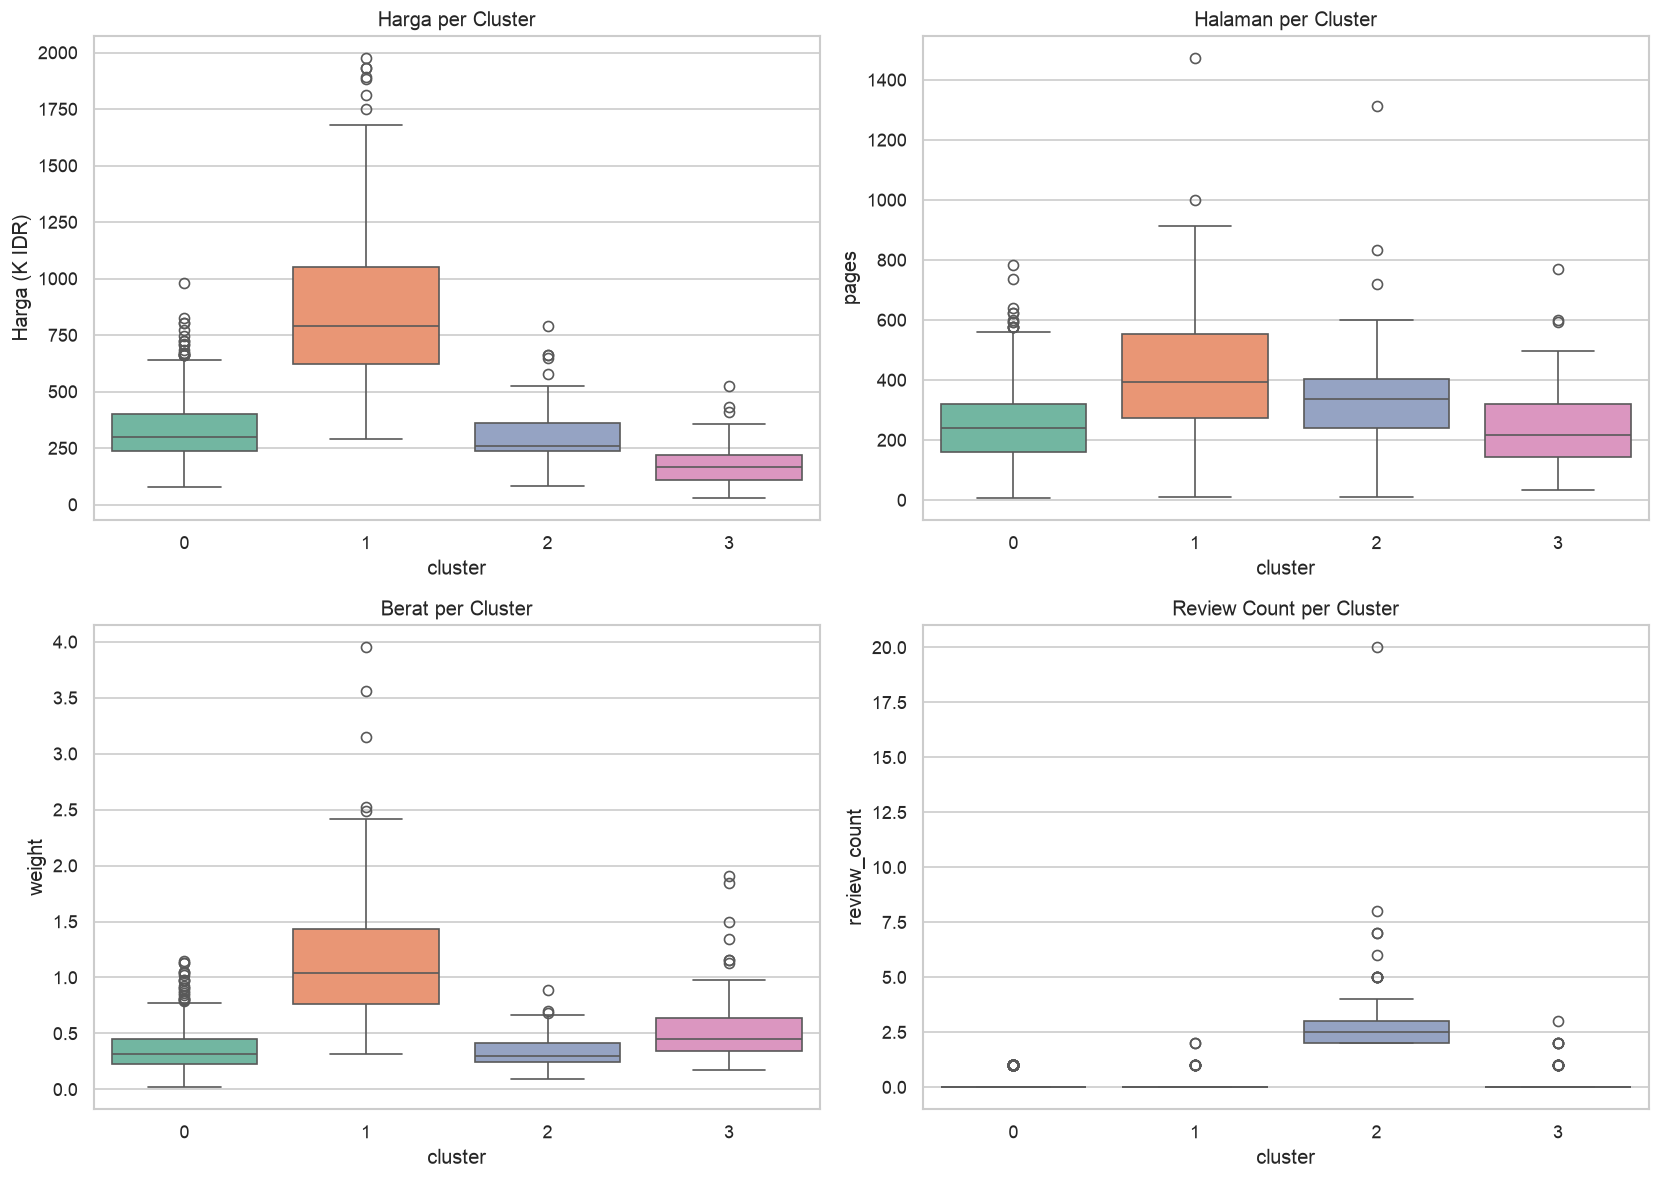

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df_clust['price_k'] = df_clust['price_idr'] / 1000

sns.boxplot(data=df_clust, x='cluster', y='price_k', palette='Set2', ax=axes[0,0])
axes[0,0].set_ylabel('Harga (K IDR)')
axes[0,0].set_title('Harga per Cluster')

sns.boxplot(data=df_clust, x='cluster', y='pages', palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Halaman per Cluster')

sns.boxplot(data=df_clust, x='cluster', y='weight', palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Berat per Cluster')

sns.boxplot(data=df_clust, x='cluster', y='review_count', palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Review Count per Cluster')

plt.tight_layout()
plt.savefig(PLOTS_DIR + '6_clusters_boxplot.png', bbox_inches='tight')
plt.show()

---
## 7. Big Data & Perkembangannya

Section ini membahas konsep Big Data, karakteristiknya, tools, tantangan, dan bagaimana analisis kita dapat di-scale.

### 7.1 Apa Itu Big Data?

**Big Data** mengacu pada dataset yang sangat besar dan kompleks sehingga tidak dapat diproses dengan tools tradisional.

#### 5V Characteristics:
| Karakteristik | Deskripsi | Contoh pada Dataset Buku |
|---|---|---|
| **Volume** | Ukuran data sangat besar | Jutaan buku dari ribuan toko |
| **Velocity** | Kecepatan data masuk/berubah | Real-time price updates |
| **Variety** | Beragam format data | Text, images, reviews, ratings |
| **Veracity** | Keakuratan data | Missing values, inconsistencies |
| **Value** | Nilai bisnis dari insight | Pricing strategy, recommendations |

### 7.2 Dataset Kita vs Big Data

In [29]:
current_rows = len(df)
mem_mb = df.memory_usage(deep=True).sum() / (1024**2)

scenarios = [
    ('Current', current_rows, mem_mb),
    ('10x Scale', current_rows * 10, mem_mb * 10),
    ('100x Scale', current_rows * 100, mem_mb * 100),
    ('1000x Scale', current_rows * 1000, mem_mb * 1000),
    ('Amazon-scale', 350_000_000, mem_mb * (350_000_000 / current_rows)),
]

sc_df = pd.DataFrame(scenarios, columns=['Scenario', 'Rows', 'Memory (MB)'])
sc_df['Memory (GB)'] = (sc_df['Memory (MB)'] / 1024).round(2)
sc_df['Rows'] = sc_df['Rows'].apply(lambda x: f'{x:,.0f}')
sc_df['Memory (MB)'] = sc_df['Memory (MB)'].apply(lambda x: f'{x:,.1f}')
sc_df

,Scenario,Rows,Memory (MB),Memory (GB)
0,Current,"1,322",1.0,0.00
1,10x Scale,"13,220",9.7,0.01
2,100x Scale,"132,200",97.2,0.09
3,1000x Scale,"1,322,000",972.5,0.95
4,Amazon-scale,"350,000,000","257,462.6",251.43


### 7.3 Tools & Teknologi Big Data

#### Storage & Processing
| Tool | Fungsi | Kapan Digunakan |
|---|---|---|
| **Hadoop HDFS** | Distributed file storage | Dataset > 100GB |
| **Apache Spark** | Distributed processing | Analisis paralel & ML |
| **Dask** | Python parallel computing | Pandas-like API untuk big data |
| **Apache Kafka** | Real-time streaming | Live updates & events |

#### Cloud Platforms
| Platform | Services |
|---|---|
| **AWS** | S3, Redshift, EMR, SageMaker |
| **Google Cloud** | BigQuery, Dataflow, Vertex AI |
| **Azure** | Data Lake, Synapse, Databricks |

### 7.4 Scaling Strategy

| Task | Current | Big Data |
|---|---|---|
| Data Loading | `pd.read_csv()` | `dask.read_csv()` / Spark |
| Processing | `df.groupby()` | Lazy eval + parallel |
| ML | scikit-learn | Spark MLlib / Dask-ML |
| Storage | CSV | Parquet (columnar, compressed) |
| Database | SQLite/CSV | PostgreSQL / BigQuery |

### 7.5 Tren Big Data (2024-2026)
1. **AI/ML Integration** - AutoML, LLMs, MLOps
2. **Real-time Analytics** - Event-driven architectures
3. **Data Lakehouse** - Delta Lake, Apache Iceberg
4. **Serverless** - BigQuery, Snowflake, Databricks
5. **Data Governance** - Compliance automation, federated learning

---
## 8. Kesimpulan

Proyek ini telah menganalisis dataset buku dari Periplus.com dengan 7 teknik:

1. **Manajemen Data** - Scraping, cleaning, feature engineering (1,328 rows x 23 kolom)
2. **Korelasi** - Korelasi kuat antara harga-halaman-berat
3. **Asosiasi** - Pola publisher-category dan price-discount teridentifikasi
4. **Regresi** - Random Forest memprediksi harga dengan akurasi tinggi
5. **Klasifikasi** - Model klasifikasi popularitas, price category, dan diskon
6. **Clustering** - Segmentasi buku menjadi 4 cluster bermakna
7. **Big Data** - Pemahaman tools dan arsitektur untuk scaling

### Manfaat untuk E-Commerce:
- **Pricing Strategy** - Prediksi harga optimal
- **Targeted Marketing** - Segmentasi berdasarkan cluster
- **Inventory Management** - Stock allocation berdasarkan popularitas
- **Recommendation** - Rekomendasi buku berdasarkan pola asosiasi

---
*Tugas Data Science IF404 - PJJ Informatika S1 - 2026*